In [60]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import math
from cycler import cycler

# Define high-contrast color palette
# 1. Deep Blue, 2. Brick Red, 3. Forest Green, 4. Muted Purple, 5. Safety Orange, 
# 6. Chestnut Brown, 7. Raspberry Pink, 8. Slate Gray, 9. Olive Gold, 10. Teal/Cyan

general_colors = ['#1f77b4','#d62728','#2ca02c','#9467bd','#ff7f0e','#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf' ]
light_colors = ['#0047AB',  '#FF0000',  '#00CC00',  '#9932CC',  '#FF8C00',  '#FF00FF',  '#FFD700',  '#00CED1',  '#FF4500',  '#7FFF00']

# General graph settings
plt.rcParams.update({
    # Font settings
    'font.family': 'sans-serif',          # Universal font family
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'], # Fallback fonts
    # 'font.family': 'serif',          # Cambiato da sans-serif a serif
    # 'font.serif': ['Computer Modern', 'Times New Roman', 'DejaVu Serif'], # Lista di font serif
    'mathtext.fontset': 'cm',        # Imposta i simboli matematici nello stile di LaTeX (Computer Modern
    # 'mathtext.fontset': 'stix',           # Makes LaTeX math symbols match the text font style
    
    # Color cycle settings
    'axes.prop_cycle': cycler(color=light_colors), # Sets the default color sequence for multiple lines
    
    # Size and resolution
    'font.size': 14,                      # General font size
    'axes.labelsize': 14,                 # Size of axis labels (x, y)
    'axes.titlesize': 16,                 # Size of the plot title
    'legend.fontsize': 12,                # Legend font size
    
    # Line and marker aesthetics
    'lines.linewidth': 2,                 # Line width
    'lines.markersize': 5,                # Marker size
    'figure.figsize': (10, 6),            # Default figure size
    
    # Grid settings
    'axes.grid': True,                    # Enable grid by default
    'grid.alpha': 0.4,                    # Make grid slightly transparent
    'grid.linestyle': '--',               # Dashed grid style
    'errorbar.capsize': False             # Add caps to error bars
})

# Exercise 07



## Exercise 07.1
### Assignment

In the NSL simulator code we have provided, include tail corrections for potential energy, $U$, and pressure $P$.


### Solution

Here is reported the code implemented
```c++
if( property == "POTENTIAL_ENERGY" ){
    // ...
    _vtail = 8.0 * M_PI * _rho * ( (1.0 / (9.0 * std::pow(_r_cut, 9))) - (1.0 / (3.0 * std::pow(_r_cut, 3))) );
} else if( property == "PRESSURE" ){
    // ...
    _ptail = 32.0 * M_PI * _rho * _rho * ((1.0 / (9.0 * std::pow(_r_cut, 9))) - (1.0 / (6.0 * std::pow(_r_cut, 3))));
}
```

## Exercise 07.2
### Assignment

Use the NSL simulator code to print out **instantaneous** values of potential energy per particle, $U/N$, along **equilibrated** Monte Carlo $(N,V,T)$ and Molecular Dynamics $(N,V,E)$ simulations of $M=5\times 10^5$ MC steps or MD time steps (where, for MC, the Metropolis acceptance ratio should be fixed approximately to 50% by changing the value of $dt$ that, in the MC case, represent the amplitude of the step in each direction) in the following thermodynamic conditions:
- liquid phase: $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r^\star_c = 2.5$, for MD $dt^\star=0.001$)

Equilibration is needed both with MC and with MD. With MD, you will observe that starting from a perfect crystalline configuration the temperature, $T$, will not conserve its value. Explore and find the starting value of $T$ needed to stabilize, after a certain number of time steps (equilibration time), the average value of $T$ on the desired $T^\star$.
Perform your MC and MD simulations by re-starting after such equilibration time.

1. Once this data has been produced, compute and make pictures with a python script of the autocorrelation functions of $U/N$ $to approximately estimate how large the blocks in your simulations should be.
2. Use the same data to study, with a python script, the estimation of the statistical uncertainties of the expectation value of $U/N$ for different size of the blocks in the data blocking technique, from $L=M/N=10$ to $L=5\times 10^3$, being $N$ the number of blocks. Make pictures of these statistical uncertainties as a function of $L$. What you observe in the statistical uncertainties after that the block size is large enough (from the point of view of the data blocking technique)?

### Solution

I have to perform a MonteCarlo sim and a MolecularDinamics sim with:
-  $5\times 10^5$ throws, $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r^\star_c = 2.5$)

OUTPUT_MC
- $dt=0.1$ I verified that gave an acceptance around 50%.

OUTPUT_MD
- $dt^\star=0.001$

First, I explore high and low values of temperature, to find the starting point needed to equilibrate at T=1.1. I perform a plot of T for different initial conditions, to see how long does it take to equilibrate.

/tmp/ipykernel_1186/2567617252.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend(loc='best', frameon=True)


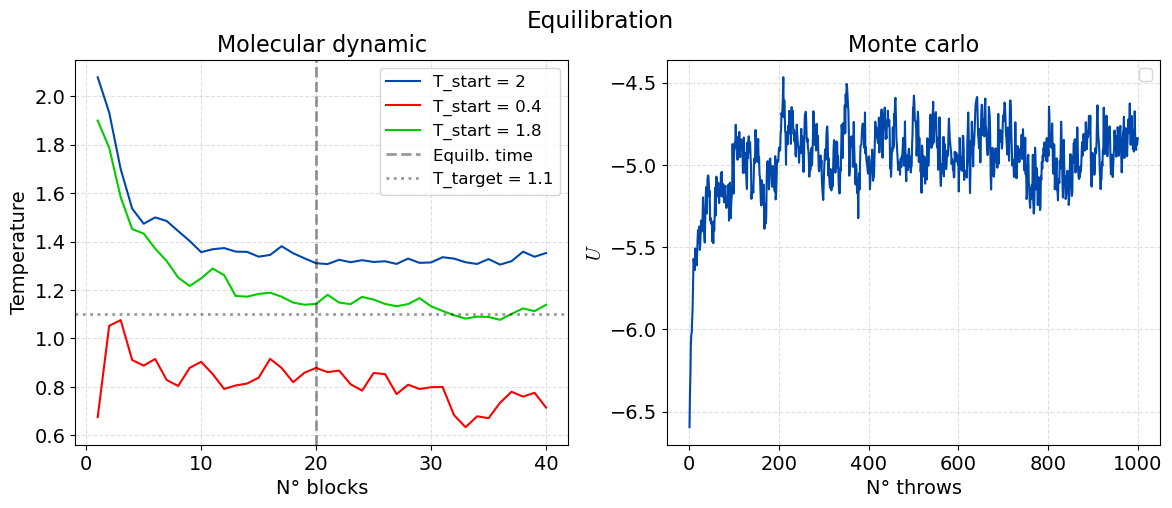

In [61]:
high_t = np.loadtxt("NSL_SIMULATOR/OUTPUT_MD_20k_2°/temperature.dat")
desired_t = np.loadtxt("NSL_SIMULATOR/OUTPUT_MD_20k_1.8°/temperature.dat")
low_t = np.loadtxt("NSL_SIMULATOR/OUTPUT_MD_20k_0.4°/temperature.dat")

monte_carlo = np.loadtxt("NSL_SIMULATOR/OUTPUT_MC_test/potential_energy.dat")

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(14, 5))
fig.suptitle('Equilibration')

ax[0].plot(high_t[:, 0], high_t[:, 1], label='T_start = 2', linewidth=1.5)
ax[0].plot(low_t[:, 0], low_t[:, 1], label='T_start = 0.4', linewidth=1.5)
ax[0].plot(desired_t[:, 0], desired_t[:, 1], label='T_start = 1.8',  linewidth=1.5)
ax[0].axvline(20, color='black', linestyle='--', alpha=0.4, label='Equilb. time')
ax[0].axhline(1.1, color='black', linestyle=':', linewidth=2, alpha=0.4, label='T_target = 1.1')
ax[0].set_title("Molecular dynamic")
ax[0].set_xlabel('N° blocks')
ax[0].set_ylabel('Temperature')
ax[0].legend(loc='best', frameon=True)

ax[1].plot(monte_carlo[:, 0], monte_carlo[:, 1], linewidth=1.5)
ax[1].set_title("Monte carlo")
ax[1].set_xlabel('N° throws')
ax[1].set_ylabel('$U$')
ax[1].legend(loc='best', frameon=True)

With these data I set the equilibration time at around $20 \times 500 = 1 \times 10^4$ steps, and the start temperature at $1.8$.
Monte carlo equilibrates after few hundred steps.

I now generate a MD sim and a MC sim of $5 \times 10^5$ steps, and I print instantaneous values of potential energy. To do so, I added a new parameter in the file input.dat, "INSTANTANEOUS", which instructs the program to print instantaneous value of potential energy on a new file "instantaneous_penergy.dat". I also print the evolution of the various type of energies.

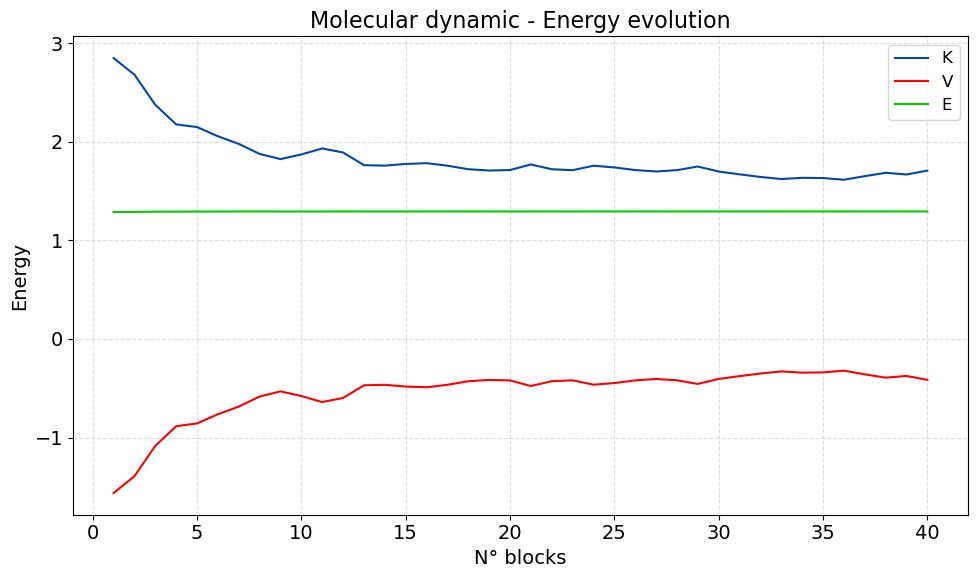

In [62]:
K = np.loadtxt("NSL_SIMULATOR/OUTPUT_MD_20k_1.8°/kinetic_energy.dat")
V = np.loadtxt("NSL_SIMULATOR/OUTPUT_MD_20k_1.8°/potential_energy.dat")
E = np.loadtxt("NSL_SIMULATOR/OUTPUT_MD_20k_1.8°/total_energy.dat")

plt.plot(K[:, 0], K[:, 1], label='K', linewidth=1.5)
plt.plot(V[:, 0], V[:, 1], label='V', linewidth=1.5)
plt.plot(E[:, 0], E[:, 1], label='E', linewidth=1.5)

# Graphic elements
plt.title("Molecular dynamic - Energy evolution")
plt.xlabel('N° blocks')
plt.ylabel('Energy')
plt.legend(loc='best', frameon=True)
plt.tight_layout()
plt.show()

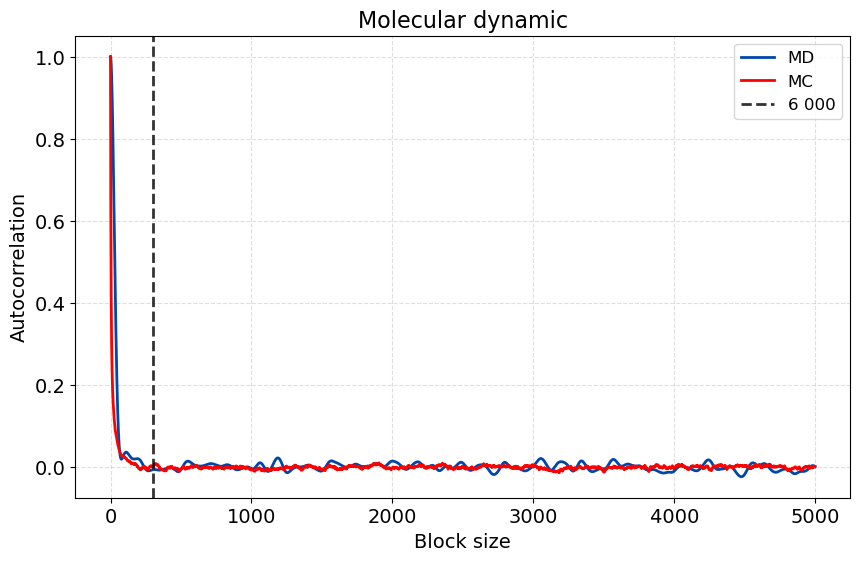

In [63]:
def calcola_autocorrelazione(x, max_lag):
    """ Calcola l'autocorrelazione di una serie temporale x per ritardi (lag) da 0 a max_lag. """
    n = len(x)
    ac = np.zeros(max_lag)
    
    # La varianza globale del set di dati (denominatore per normalizzare)
    var = np.var(x)
    
    for t in range(max_lag):
        # Taglio gli array per confrontare il tempo t' con il tempo t'+t
        x_inizio = x[0 : n - t]      # Dati da t'=0 fino alla fine meno t
        x_spostato = x[t : n]        # Dati da t'=t fino alla fine assoluta
        
        # Formula dell'autocorrelazione per il lag 't'
        # <x(t')*x(t'+t)> - <x(t')>*<x(t'+t)>
        cov = np.mean(x_inizio * x_spostato) - np.mean(x_inizio) * np.mean(x_spostato)
        
        # Normalizziamo dividendo per la varianza
        ac[t] = cov / var
        
    return ac

data_MD = np.loadtxt("NSL_SIMULATOR/OUTPUT_MD_500k_1.8°_eq_v2/instantaneous_penergy.dat")
data_MC = np.loadtxt("NSL_SIMULATOR/OUTPUT_MC_500k_eq/instantaneous_penergy.dat")
max_lag = 5000

auto_correlation_MD = calcola_autocorrelazione(data_MD, max_lag)
auto_correlation_MC = calcola_autocorrelazione(data_MC, max_lag)

# fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(12, 5), constrained_layout=True)
# fig.suptitle('Autocorrelation vs block size')


plt.plot(auto_correlation_MD, label = 'MD')
plt.plot(auto_correlation_MC, label = 'MC')
plt.axvline(300, color='black', linestyle='--', alpha=0.8, label='6 000')
plt.title("Molecular dynamic")
plt.xlabel('Block size')
plt.ylabel('Autocorrelation')
plt.legend(loc='best')



- Molecular Dynamics

The data shows that the correlation between blocks reaches a minimun at around size $300$. Increasing the blocks size over this value causes the autocorrelation to oscillate vigorously around $0$.

- Monte Carlo

The data shows that the correlation between blocks reaches a minimun at around size $300$ steps. Increasing the blocks size over this value causes the autocorrelation to oscillate vigorously around $0$.

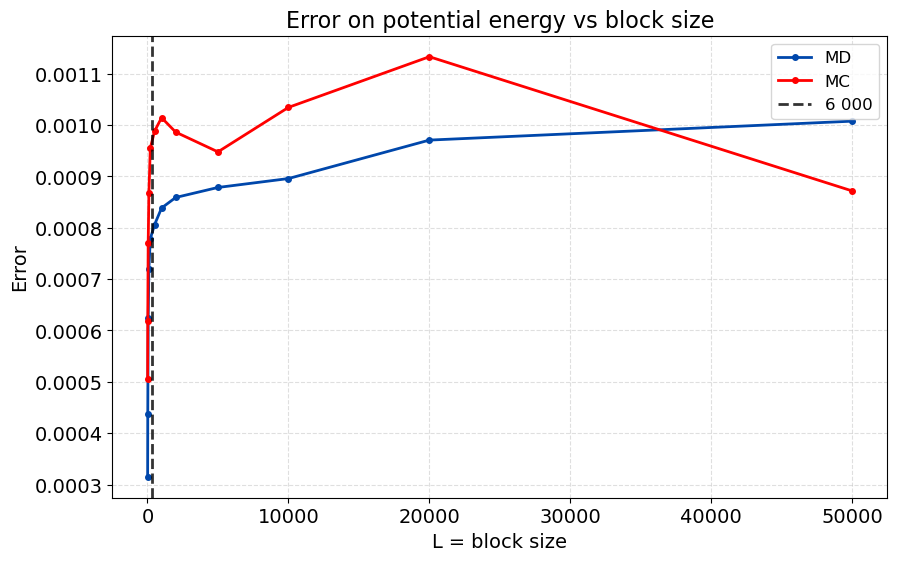

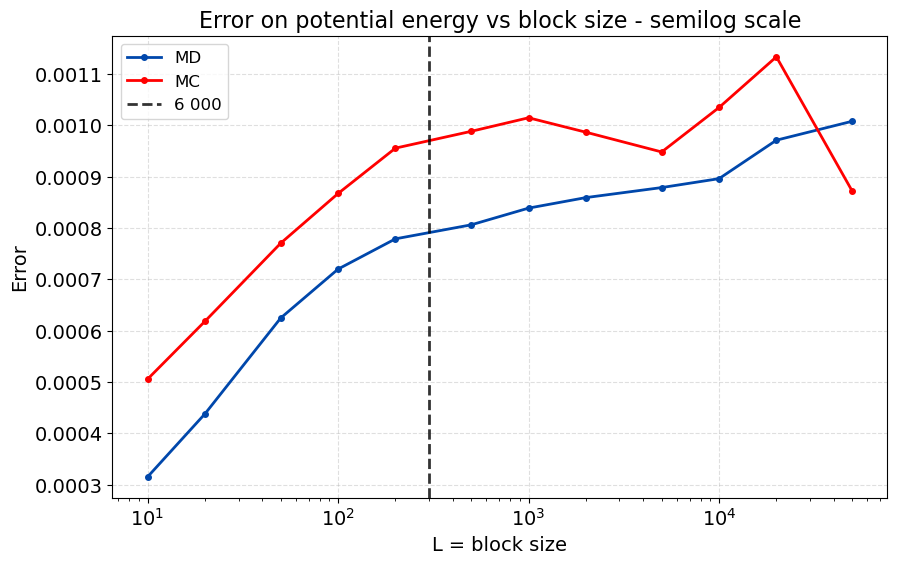

In [64]:
def calcola_errore(ave, av2, n) : 
    if n == 0 : 
        return 0
    return np.sqrt((av2 - ave * ave) / n)


def data_blocking(data, block_size):
    n_data = len(data)
    n_blocks = n_data//block_size #Divisione intera

    # Prevenzione: scarta gli ultimi dati se n_data non è un multiplo esatto di block_size
    # data = data[:n_blocks * block_size]

    ave = np.zeros(n_blocks)
    av2 = np.zeros(n_blocks)
    err_prog = np.zeros(n_blocks)

    sum_prog = np.zeros(n_blocks)
    su2_prog = np.zeros(n_blocks)
    
    current_tot = 0
    current_to2 = 0
    counter = 0

    for i in range(n_blocks) :
        provv = 0
        for j in range(block_size) : 
            provv = provv + data[counter]
            counter = counter + 1
        ave[i] = provv / block_size
        av2[i] = ave[i] * ave[i]

        current_tot = current_tot + ave[i]
        current_to2 = current_to2 + av2[i]

        sum_prog[i] = current_tot / (i+1)
        su2_prog[i] = current_to2 / (i+1)

        err_prog[i] = calcola_errore(sum_prog[i], su2_prog[i], i)

    x = np.arange(1, n_data + 1, block_size)

    return [x, ave, sum_prog, err_prog]

data_MD = np.loadtxt("NSL_SIMULATOR/OUTPUT_MD_500k_1.8°_eq_v2/instantaneous_penergy.dat")
data_MC = np.loadtxt("NSL_SIMULATOR/OUTPUT_MC_500k_eq/instantaneous_penergy.dat")

data = [data_MD, data_MC]
labels = ['MD', 'MC']
# variable_size = [10, 100, 1000, 5000]
variable_size = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000] #, 100000, 250000]

V_error = np.zeros(len(variable_size))

for index in range(2):
    for i in range(len(variable_size)) :
        block_size = variable_size[i]
        [x, ave, sum_prog, err_prog] = data_blocking(data[index], block_size)
        V_error[i] = err_prog[-1]
        # plt.errorbar(x, sum_prog, err_prog, alpha=0.4, label=f"L = {variable_size[i]}")

    # Plotto dati in funzione della dimensione dei blocchi
    plt.plot(variable_size, V_error, marker='.', markersize=8, label=labels[index])

plt.axvline(300, color='black', linestyle='--', alpha=0.8, label='6 000')
plt.xlabel('L = block size')
plt.ylabel('Error')
plt.title('Error on potential energy vs block size')
plt.legend(loc='best')
plt.show()

for index in range(2):
    for i in range(len(variable_size)) :
        block_size = variable_size[i]
        [x, ave, sum_prog, err_prog] = data_blocking(data[index], block_size)
        V_error[i] = err_prog[-1]
        # plt.errorbar(x, sum_prog, err_prog, alpha=0.4, label=f"L = {variable_size[i]}")

    # Plotto dati in funzione della dimensione dei blocchi
    plt.plot(variable_size, V_error, marker='.', markersize=8, label=labels[index])

plt.axvline(300, color='black', linestyle='--', alpha=0.8, label='6 000')
plt.xscale('log')
plt.xlabel('L = block size')
plt.ylabel('Error')
plt.title('Error on potential energy vs block size - semilog scale')
plt.legend(loc='best')
plt.show()

I observe that:
- The error on the data blocking increases until the block size is the one for wich the autocorrelation resulted to ben minimum. After that, the error starts to decrease. This is another hint that the block dimension around 300 is the minimum not to have correlations.

- The error flattens after the correlation size is reached.

- In the second graph it is possible to observe an exponential (logaritmic) growth before the critical parameter, accordingly to the theory of correlation.

## Exercise 07.3
### Assignment

Include the calculation of the radial distribution function, $g(r)$, as a function of the radial distance $r$ among particles, with $r \in \left[ 0; L/2\right]$ inside the NSL simulator code: average value of $g(r)$ in each block, final average value of $g(r)$ with statistical uncertainties in a separate file.

### Solution

Here i implement the calculation of the $g(r)$. As a demo, I show a MD simulation done with 100 blocks of size 1'000, for a total of 100'000 throws. As it is possible to see from the data, the $g(r)$ is zero up until r = 1, that means r = L/2. This is the hard shell where repulsion between particles is too strong to let anything pass. 
At r = L/2, $g$ has a peak, corresponding to a region where there is a higher concentration of particles, and this might be caused by the attractive part of the Lennard-Jones potential. After this peak, the graph has another local maximum, that might be an effect of a second shell of particles, outside the first peak.


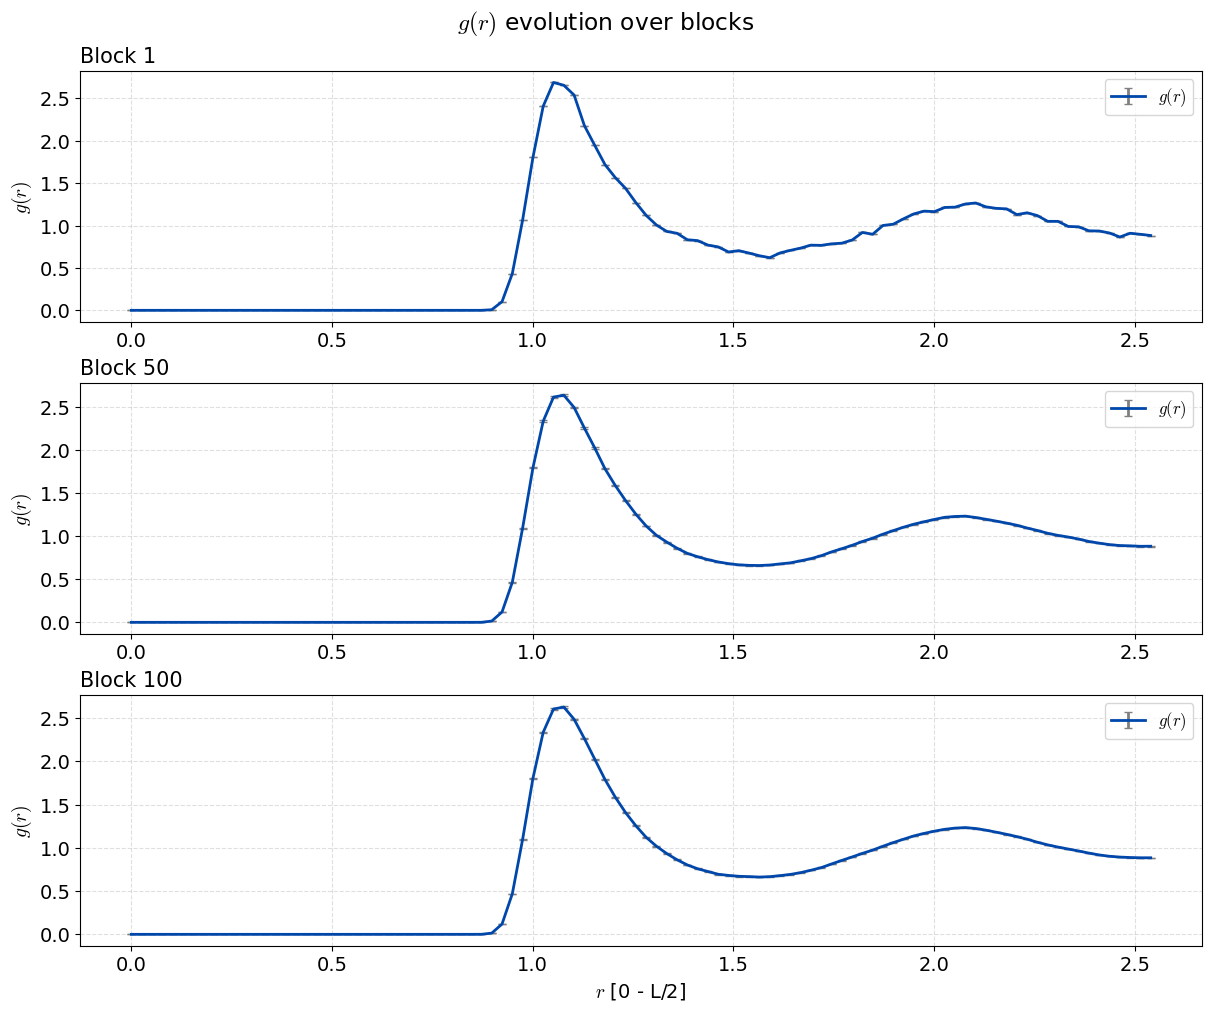

In [65]:
# Entra per prendere i dati di gofr
data = np.loadtxt("NSL_SIMULATOR/OUTPUT_MD_100k_gofr/gofr.dat")

with open("NSL_SIMULATOR/OUTPUT_MD_100k_gofr/output.dat", "r") as file:
    # Trasforma tutto il file in una lista di singole parole/numeri
    tokens = file.read().split()

try:
    # Trova la posizione (indice) di "GOFR" e di "NPARTS"
    # Il valore è l'elemento immediatamente successivo (indice + 1)
    indice_nb = tokens.index("NBLOCKS=")
    indice_np = tokens.index("NPART=")
    indice_rho = tokens.index("RHO=")
    indice_nbins = tokens.index("N_BINS_G=")
    
    n_blks = int(tokens[indice_nb + 1])
    n_part = int(tokens[indice_np + 1])
    rho = float(tokens[indice_rho + 1])   # conversione a float!
    n_bins = int(tokens[indice_nbins + 1])
    
except ValueError:
    print("Parola non trovata")
except IndexError:
    print("Valore non trovato")

# Setup della figura
fig, ax = plt.subplots(3, 1, figsize=(12, 10), constrained_layout=True)
fig.suptitle(r'$g(r)$ evolution over blocks')

count = 0
delta_x = data[1, 0] - data[0, 0]

for i in range(n_blks) :
    if (i == 0 or (i+1) % 50 == 0) and count < len(ax):  # Protezione per non uscire dall'indice di ax
        inizio = i * n_bins
        fine = inizio + n_bins
        
        x = data[inizio:fine, 0]
        y = data[inizio:fine, 1]
        y_prog = data[inizio:fine, 2]
        err_prog = data[inizio:fine, 3]

        # Volume e normalizzazione
        delta_V = (4.0 / 3.0) * np.pi * ((x + delta_x)**3 - x**3)
        norm_fac = rho * n_part * delta_V
        
        y_pdf = y / norm_fac
        y_prog_pdf = y_prog / norm_fac
        err_prog_pdf = err_prog / norm_fac
        
        # Plot sul singolo subplot
        # ax[count].plot(x, y_pdf,  linestyle='--', linewidth=1.5, label='g(r): single block')
        ax[count].errorbar(x, y_prog_pdf, err_prog_pdf, markersize=1, ecolor='grey', capsize =3, label='$g(r)$')
        
        # Formattazione minimale per ogni subplot
        ax[count].set_title(f"Block {i+1}", loc='left', fontsize=15)
        ax[count].set_ylabel('$g(r)$')
        ax[count].legend(loc='best', frameon=True)
        
        count += 1

#ax[-1].set_title(f"Block {n_blks}", loc='left', fontsize=10) # Correggi titolo dell'ultimo grafico
ax[-1].set_xlabel("$r$ [0 - L/2]") # Etichetta comune per l'asse X (solo sull'ultimo per pulizia)

plt.show()

## Exercise 07.4
### Assignment


By means of your upgraded NSL simulator code, equilibrate and perform MC NVT and MD NVE simulations via a Lennard-Jones model of Argon ($\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu) in the following conditions:
- liquid phase: $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r_c = 2.5$)

show in pictures the obtained average values and uncertainties for the potential energy per particle, $U/N$, the pressure $P$ and the radial distribution function $g(r)$ in LJ units ... and compare your MC results for these quantities with those obtained via MD NVE simulations in similar thermodynamic conditions.

### Solution

I equilibrate and perform MC NVT and MD NVE simulations via a Lennard-Jones model of Argon ($\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu) in the following conditions:
- liquid phase: $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r_c = 2.5$)

I show in pictures the obtained average values and uncertainties for the potential energy per particle, $U/N$, the pressure $P$ and the radial distribution function $g(r)$ in LJ units. 
The comparison between MC results for these quantities with those obtained via MD NVE simulations in similar thermodynamic conditions shows that the energy is different. 

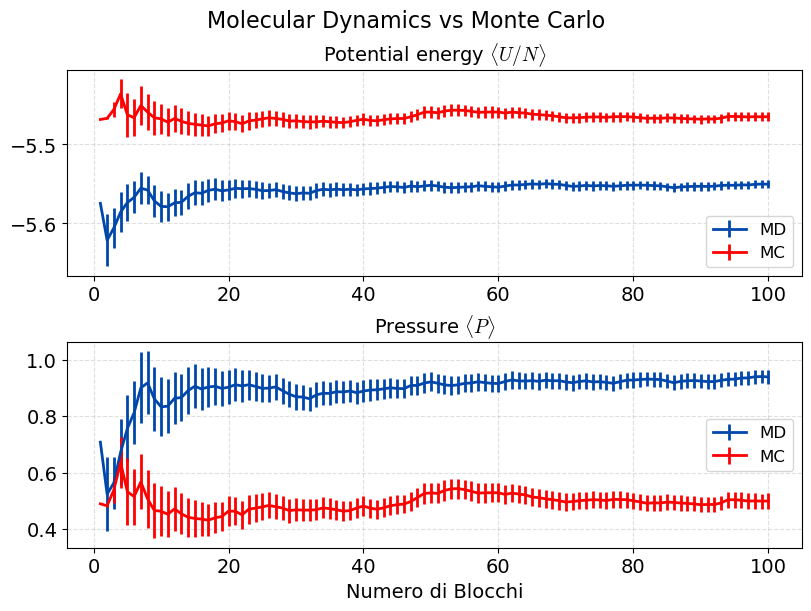

In [66]:
# 0. Carica dati

V_MD = np.loadtxt("NSL_SIMULATOR/OUTPUT_MD_10k/potential_energy.dat")
P_MD = np.loadtxt("NSL_SIMULATOR/OUTPUT_MD_10k/pressure.dat")
V_MC = np.loadtxt("NSL_SIMULATOR/OUTPUT_MC_10k/potential_energy.dat")
P_MC = np.loadtxt("NSL_SIMULATOR/OUTPUT_MC_10k/pressure.dat")

# 2. Struttura Dati
# Ogni elemento è una tupla: (blocchi, valori, errori)
dati = {
    'MD': {
        'U/N': (V_MD[:, 0], V_MD[:, 2], V_MD[:, 3]),
        'Press': (P_MD[:, 0], P_MD[:, 2], P_MD[:, 3])
    },
    'MC': {
        'U/N': (V_MC[:, 0], V_MC[:, 2], V_MC[:, 3]),
        'Press': (P_MC[:, 0], P_MC[:, 2], P_MC[:, 3])
    }
}

# Liste per automatizzare i cicli
simulazioni = ['MD', 'MC']
proprieta = ['U/N', 'Press']

# Etichette eleganti per l'asse Y
y_labels = {'U/N': r'Potential energy $\langle U/N \rangle$', 
            'Press': 'Pressure $\\langle P \\rangle$'}

# Colori per distinguere a colpo d'occhio
colori = {'MD': light_colors[0], 'MC': light_colors[1]}

# 3. Creazione della figura
# sharey='row' allinea l'asse Y per la stessa proprietà, rendendo il confronto MD vs MC immediato
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), constrained_layout=True)

# 4. Doppio ciclo di automazione
for i, prop in enumerate(proprieta):       # Scorre le righe (U/N, poi Press)
    for j, sim in enumerate(simulazioni):  # Scorre le colonne (MD, poi MC)
        
        ax = axs[i]
        
        # Recupera i dati dal dizionario
        x, y, err = dati[sim][prop]
        
        # Disegna il grafico con errorbar
        ax.errorbar(x, y, yerr=err, color=colori[sim], label=sim,
                    linestyle='-')
        
        # --- GESTIONE INTELLIGENTE DI TITOLI E LABEL ---

        ax.legend(loc='best')
        
        # Mettiamo il titolo (MD o MC) solo sulla primissima riga
        ax.set_title(y_labels[prop], fontsize=14)

        # Mettiamo l'etichetta X solo sull'ultima riga
        if i == len(proprieta) - 1:
            ax.set_xlabel('Numero di Blocchi')
    
fig.suptitle("Molecular Dynamics vs Monte Carlo", fontsize=16)
plt.show()

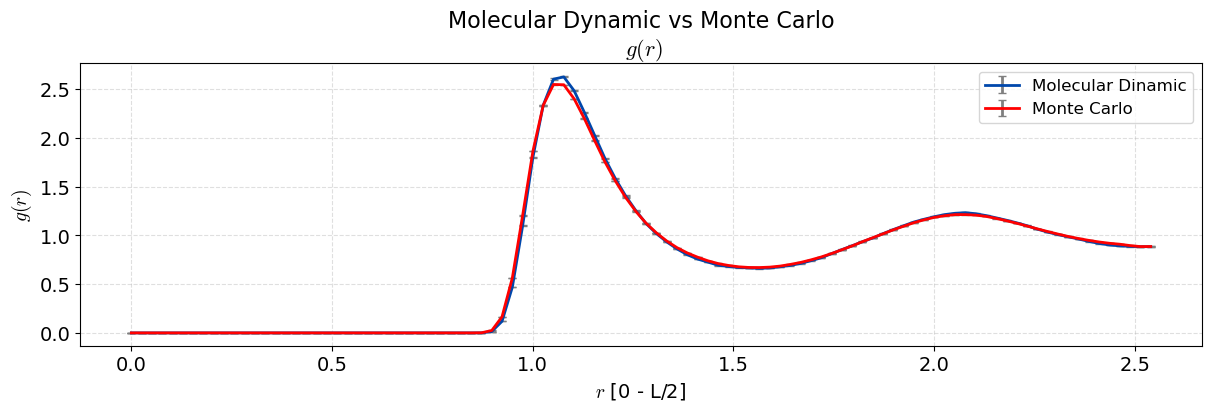

In [67]:
# LEGGO GOFR FINALE DAL FILE SEPARATO "gofr_final.dat"

filepaths = ["NSL_SIMULATOR/OUTPUT_MD_100k_gofr/gofr_final.dat", 
             "NSL_SIMULATOR/OUTPUT_MC_100k_gofr/gofr_final.dat"]
labels = ['Molecular Dinamic', 'Monte Carlo']

output_paths = ["NSL_SIMULATOR/OUTPUT_MD_100k_gofr/output.dat", 
                "NSL_SIMULATOR/OUTPUT_MC_100k_gofr/output.dat"]


plt.figure(figsize=(12, 4), constrained_layout=True)
i=0
for index, path in enumerate(filepaths):
    # Entra per prendere i dati
    data = np.loadtxt(path)

    with open(output_paths[index], "r") as file:
        # Trasforma tutto il file in una lista di singole parole/numeri
        tokens = file.read().split()

    try:
        # Trova la posizione (indice) di "GOFR" e di "NPARTS"
        # Il valore è l'elemento immediatamente successivo (indice + 1)
        indice_nb = tokens.index("NBLOCKS=")
        indice_np = tokens.index("NPART=")
        indice_rho = tokens.index("RHO=")
        indice_nbins = tokens.index("N_BINS_G=")
        
        n_blks = int(tokens[indice_nb + 1])
        n_part = int(tokens[indice_np + 1])
        rho = float(tokens[indice_rho + 1])   # conversione a float!
        n_bins = int(tokens[indice_nbins + 1])
        
    except ValueError:
        print("Parola non trovata")
    except IndexError:
        print("Valore non trovato")
    
    delta_x = data[1, 0] - data[0, 0]

    x = data[:, 0]
    y = data[:, 1]
    y_prog = data[:, 2]
    err_prog = data[:, 3]

    # Volume e normalizzazione
    delta_V = (4.0 / 3.0) * np.pi * ((x + delta_x)**3 - x**3)
    norm_fac = rho * n_part * delta_V

    y_pdf = y / norm_fac
    y_prog_pdf = y_prog / norm_fac
    err_prog_pdf = err_prog / norm_fac

    # plt.plot(x, y_pdf, color='tab:blue', linewidth=1, linestyle='--', label='g(r): single block')
    plt.errorbar(x, y_prog_pdf, err_prog_pdf, color=light_colors[i], markersize=1, ecolor='grey', capsize =3, label=labels[i])
    i=i+1
plt.title("Molecular Dynamic vs Monte Carlo\n $g(r)$ ", fontsize=16)
plt.ylabel('$g(r)$')
plt.xlabel("$r$ [0 - L/2]") 
plt.legend(loc='best', frameon=True)
plt.show()

As shown in the plots, the $g(r)$ obtained via Monte Carlo NVT and Molecular Dynamics NVE simulations exhibits a near-perfect overlap. This confirms that both sampling algorithms correctly capture the spatial structure of system. Conversely, a systematic offset is visible between the two methods when observing the Potential Energy per particle $U/N$ and the Pressure $P$. This discrepancy is a practical consequence of the equilibration protocols in finite systems: In the MC NVT simulation, the system strictly explores configurations exactly at the target continuous temperature $T^\star = 1.1$. In the MD NVE simulation, after the velocity-rescaling equilibration phase, the system evolves at constant total energy. The resulting time-averaged temperature $T_{MD}$ may not perfectly match the exact target value of $1.1$. Because thermodynamic observables like $U/N$ and $P$ are sensitive to $T$, even a slight deviation in the equilibrated MD temperature translates into the constant vertical offset observed in the respective progression plots.